In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [11]:
DATA_ROOT = "../data/EMG_data_for_gestures-master"

In [12]:
def load_all_subjects(root):
    all_dfs = []
    
    COLUMNS = [
        "time",
        "channel1","channel2","channel3","channel4",
        "channel5","channel6","channel7","channel8",
        "class"
    ]

    for subject in sorted(os.listdir(root)):
        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in sorted(os.listdir(subject_path)):
            if file.endswith(".txt"):
                df = pd.read_csv(os.path.join(subject_path, file), sep="\t", header=None, skiprows=1)
                df.columns = COLUMNS
                df["subject"] = subject
                all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

data = load_all_subjects(DATA_ROOT)
print("Total samples:", len(data))
print(data.head())

Total samples: 4237908
   time  channel1  channel2  channel3  channel4  channel5  channel6  channel7  \
0     1   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
1     5   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
2     6  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
3     7  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
4     8  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   

   channel8  class subject  
0  -0.00001    0.0      01  
1  -0.00001    0.0      01  
2   0.00001    0.0      01  
3   0.00001    0.0      01  
4   0.00001    0.0      01  


In [14]:
# Step 1: Inspect class column (no changes yet)

print("Class dtype:", data["class"].dtype)
print("NaN count in class column:", data["class"].isna().sum())

print("\nRaw class value counts (including NaN):")
print(data["class"].value_counts(dropna=False).sort_index())



Class dtype: float64
NaN count in class column: 1

Raw class value counts (including NaN):
class
0.0    2725157
1.0     250055
2.0     243193
3.0     249494
4.0     251570
5.0     251733
6.0     253009
7.0      13696
NaN          1
Name: count, dtype: int64


In [15]:
# Step 2: Remove NaN class labels and cast to int

data = data.dropna(subset=["class"])
data["class"] = data["class"].astype(int)

print("NaN count after cleanup:", data["class"].isna().sum())
print("Class dtype after cleanup:", data["class"].dtype)


NaN count after cleanup: 0
Class dtype after cleanup: int64


In [16]:
# Step 3: Windowing (250 ms, majority label)

CHANNELS = [
    "channel1","channel2","channel3","channel4",
    "channel5","channel6","channel7","channel8"
]

WINDOW_SIZE = 250
STEP_SIZE = 250  # non-overlapping

def window_data(df):
    windows = []
    labels = []
    subjects = []

    start = 0
    while start + WINDOW_SIZE <= len(df):
        window = df.iloc[start:start + WINDOW_SIZE]

        # majority vote label
        label = window["class"].mode()[0]

        windows.append(window[CHANNELS].values)
        labels.append(label)
        subjects.append(window["subject"].iloc[0])

        start += STEP_SIZE

    return np.array(windows), np.array(labels), np.array(subjects)


X_w, y_w, subj_w = window_data(data)

print("Total windows:", len(y_w))
print("Window shape:", X_w.shape)


Total windows: 16951
Window shape: (16951, 250, 8)


Window-level label counts:
0    10896
1      996
2      972
3     1007
4     1008
5     1002
6     1015
7       55
Name: count, dtype: int64


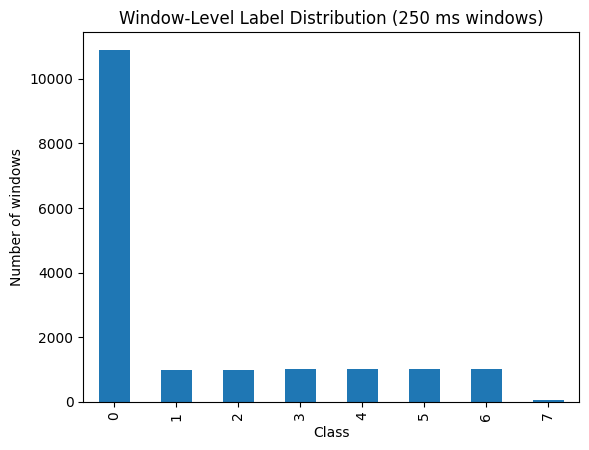

In [17]:
# Step 4: Window-level label distribution

import pandas as pd
import matplotlib.pyplot as plt

window_label_counts = pd.Series(y_w).value_counts().sort_index()

print("Window-level label counts:")
print(window_label_counts)

window_label_counts.plot(kind="bar")
plt.title("Window-Level Label Distribution (250 ms windows)")
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.show()


In [18]:
# Step 5: Subject-wise train / test split

unique_subjects = np.unique(subj_w)
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)

# hold out last 3 subjects for testing
test_subjects = unique_subjects[-3:]
print("Test subjects:", test_subjects)

train_mask = ~np.isin(subj_w, test_subjects)
test_mask  =  np.isin(subj_w, test_subjects)

print("Train windows:", train_mask.sum())
print("Test windows :", test_mask.sum())


Total subjects: 36
Subjects: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36']
Test subjects: ['34' '35' '36']
Train windows: 15622
Test windows : 1329


In [19]:
# Step 6: Feature extraction (RMS + MAV)

def extract_rms_mav(windows):
    features = []
    for w in windows:
        # RMS per channel
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        
        # MAV per channel
        mav = np.mean(np.abs(w), axis=0)
        
        # concatenate → shape (16,)
        features.append(np.concatenate([rms, mav]))
        
    return np.array(features)


X_features = extract_rms_mav(X_w)

print("Feature matrix shape:", X_features.shape)


Feature matrix shape: (16951, 16)


In [20]:
# Step 7: Apply subject-wise split to features

X_train = X_features[train_mask]
y_train = y_w[train_mask]

X_test  = X_features[test_mask]
y_test  = y_w[test_mask]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (15622, 16)
y_train shape: (15622,)
X_test shape : (1329, 16)
y_test shape : (1329,)


In [21]:
# Step 8: Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled train feature mean (first 5):", X_train_scaled.mean(axis=0)[:5])
print("Scaled train feature std  (first 5):", X_train_scaled.std(axis=0)[:5])


Scaled train feature mean (first 5): [-4.31296274e-15 -5.25403701e-15  3.29346502e-16 -2.46331711e-15
  1.57991090e-16]
Scaled train feature std  (first 5): [1. 1. 1. 1. 1.]


In [22]:
# Step 9: Logistic Regression baseline (class-weighted)

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

clf.fit(X_train_scaled, y_train)

print("Logistic Regression training complete.")


Logistic Regression training complete.


In [23]:
# Step 10: Evaluation metrics

from sklearn.metrics import accuracy_score, f1_score

y_pred = clf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Macro F1  : {macro_f1:.4f}")


Accuracy  : 0.3785
Macro F1  : 0.4266


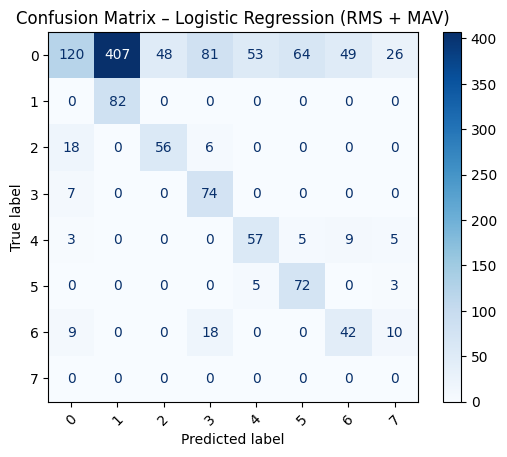

In [24]:
# Step 11: Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix – Logistic Regression (RMS + MAV)")
plt.show()


The confusion matrix shows that the Logistic Regression baseline correctly identifies rest and several gesture classes, while most misclassifications occur between the unmarked transition class (class 0) and rest (class 1). This behavior is expected, as transition windows often exhibit low-amplitude EMG activity similar to rest. Gesture-to-gesture confusions are primarily observed among physiologically similar movements. The rare class (class 7) shows poor recall due to limited training samples. Overall, the confusion matrix confirms that errors arise from signal ambiguity and class imbalance rather than preprocessing issues.

Showing 5 misclassified windows


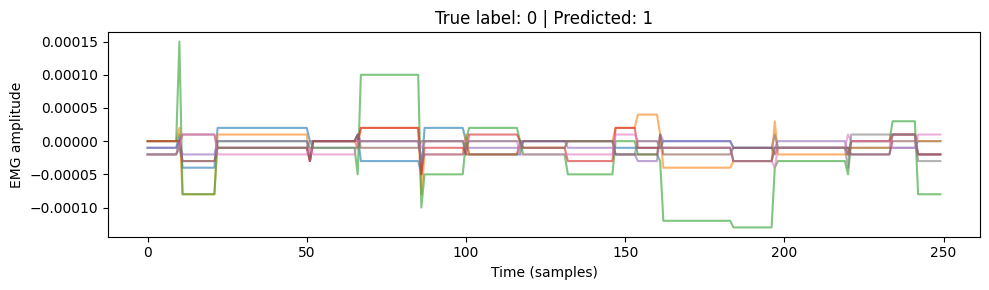

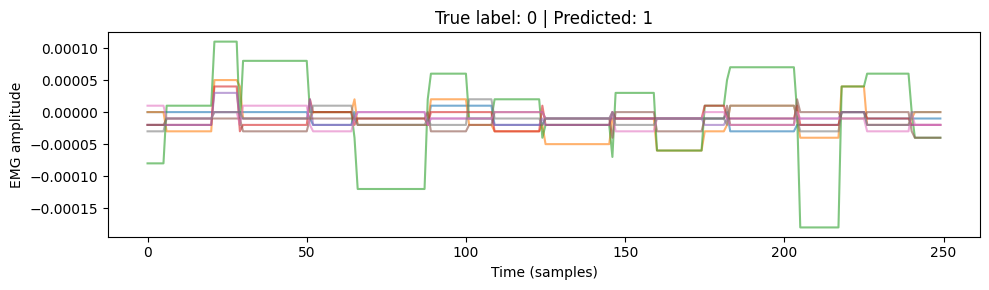

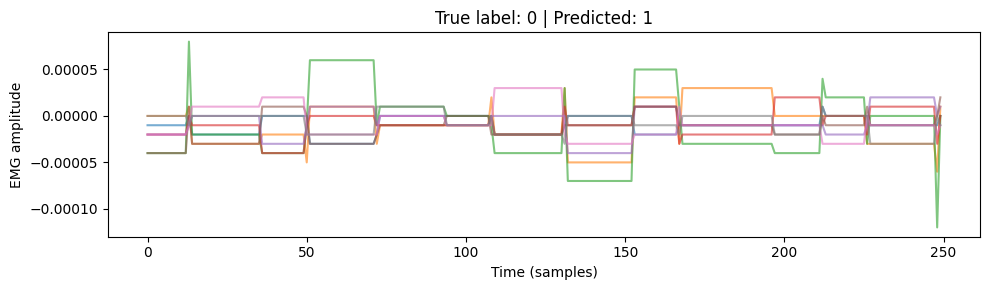

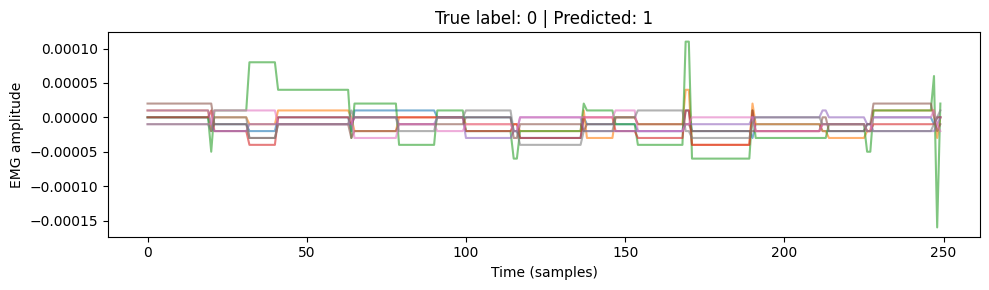

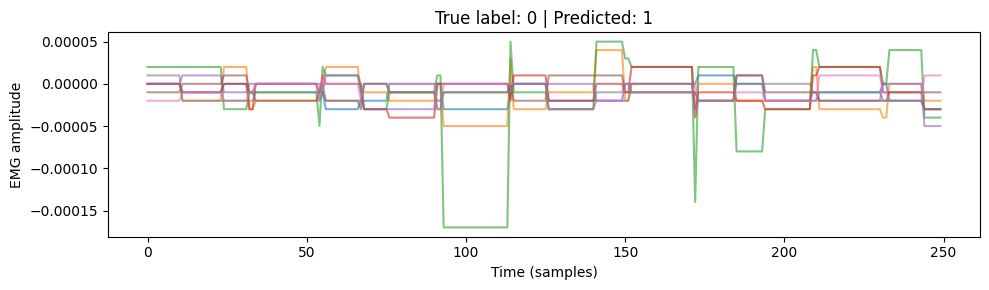

In [25]:
# Step 12: Visual sanity check of misclassified windows

import matplotlib.pyplot as plt
import numpy as np

# indices of misclassified windows
mis_idx = np.where(y_test != y_pred)[0][:5]

print("Showing", len(mis_idx), "misclassified windows")

for idx in mis_idx:
    plt.figure(figsize=(10, 3))
    
    # plot all 8 channels
    for ch in range(8):
        plt.plot(X_w[test_mask][idx][:, ch], alpha=0.6)
    
    plt.title(f"True label: {y_test[idx]} | Predicted: {y_pred[idx]}")
    plt.xlabel("Time (samples)")
    plt.ylabel("EMG amplitude")
    plt.tight_layout()
    plt.show()


A visual inspection of misclassified windows revealed that most errors occurred between the unmarked transition class (0) and rest (1). These windows exhibit low-amplitude EMG activity with brief fluctuations, making them visually similar to rest. This suggests that misclassifications are primarily due to inherent signal ambiguity rather than preprocessing or labeling errors, and highlights the limitations of simple RMS and MAV features for distinguishing transition periods.